## Gradient Checking

Imagine , You are part of a team working to make mobile payments available globally, and are asked to build a deep learning model to detect fraud--whenever someone makes a payment, you want to see if the payment might be fraudulent, such as if the user's account has been taken over by a hacker.

But backpropagation is quite challenging to implement, and sometimes has bugs. Because this is a mission-critical application, your company's CEO wants to be really certain that your implementation of backpropagation is correct. Your CEO says, "Give me a proof that your backpropagation is actually working!" To give this reassurance, you are going to use "gradient checking".

In [1]:
import numpy as np

from testcases import *
from gc_utils import sigmoid,relu, dictionary_to_vector, vector_to_dictionary, gradients_to_vector



## How does Gradient Checking Work....?

Backpropagation computes the gradients $\frac{dJ}{d\theta} $ where $\theta$  denotes the parameters of the model. J is computed using the forward propagation and with the loss function.

The def: of derivative of gradient is
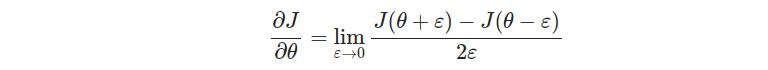

## 1D gradient checking
Consider a 1D linear function . $J{(\theta)} = \theta_x$ The model contains only a single real-valued parameter $\theta$, and takes x as input.

We implment code to compute J(.) and its derivative $\frac{dw}{d\theta} $. We then use gradient checking to make sure the derivative computation for J is correct.

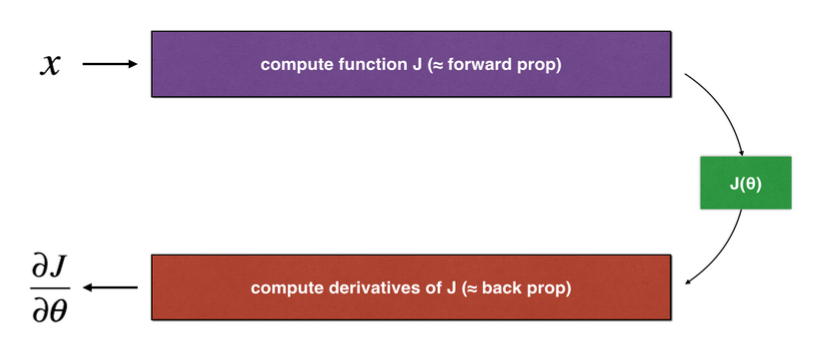

**This is a liner model**

The diagram above shows the key computation steps:
First we start with x, then evaluat the fuction J(x) ("forward propagation").Then we compure the derivative $\frac{d_J}{d_\theta}$ ("backward propagation").

Next we implement forward and backward propagation for this simple function. I.e compute both J(.) and its derivative w.r.t $\theta$,("backward propagation") in 2 seperate functions.

In [2]:
def forward_propagation(x, theta):
  """
  Implement the linear forward propagation (compute J) presented in Figure 1 (J(theta) = theta * x)

  Arguements:
  x - a real valued input
  theta -- the parameter,a real number as well.

  Returns:
  J -- the value of function J, computed using the formula J(theta) = theta * x
  """

  J = np.dot(theta, x)
  return J






In [3]:
x, theta = 2, 4
J = forward_propagation(x, theta)
print('J = ' + str(J))

J = 8


Next we implement the backward propagation i.e. the derivative of the $J{(\theta)} = \theta_x  w.r.t\ \theta$
To save from doing the calculus
We should ge the dtheta = $\frac{dJ}{d_theta}$= x

In [4]:
def backward_propagation(x, theta):
  """
  Computes the der: of J w.r.t  theta

  Args:
  x -- a real no
  theta -- the parameter, a real number as well

  Returns
  dtheta -- the grad: of the cost w.r.t theta
  """

  dtheta = x
  return dtheta


In [5]:
x, dtheta = 2, 4
dtheta = backward_propagation(x, theta)
print('dtheta = ' + str(dtheta))

dtheta = 2


To show the `backwar_propagation()` function is correctly computing the grad: $\frac{dJ}{d\theta}$ let's implement the grad:checking.


* Instructions
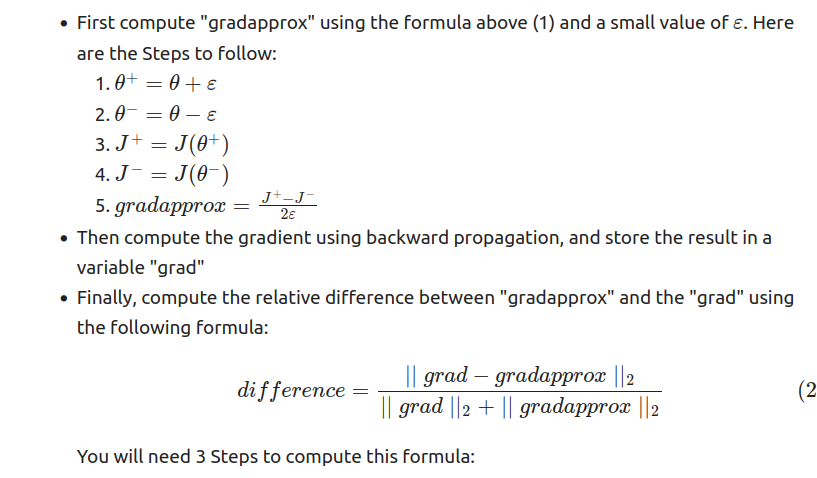


We need 3 steps to compute the formula:
* 1 Compute the numerator using np.linalg.norm(..)
* 2. Compute the denominator. We need to call np.linalg.norm(...) twice
* 3. divide them


In [6]:
def gradient_check(x, theta, epsilon=1e-7):
  thetaplus = theta + epsilon
  thetaminus = theta - epsilon
  J_plus = forward_propagation(x, thetaplus)
  J_minus = forward_propagation(x, thetaminus)
  gradapprox = (J_plus - J_minus)/(2*epsilon)

  grad = backward_propagation(x, theta)

  numerator =  np.linalg.norm(grad - gradapprox)            # step1
  denominator = np.linalg.norm(grad) + np.linalg.norm(gradapprox)    # Step 2'
  difference = numerator/denominator

  if difference < 1e-7:
    print("The gradient is correct!")
  else:
    print("The gradient is wrong!")
  return difference









In [7]:
x, theta = 2, 4
difference = gradient_check(x, theta)
print("difference" + str(difference))

The gradient is correct!
difference2.919335883291695e-10


the difference is smaller than 10. So we can have high confidence that we correctly computed the gradient in `backward_propagation()`
Now, in the more general case, your cost function J has more than a single 1D input. When you are training a neural network, $\theta$ actually consists of multiple matrices $W^[l]$ and biases $b^[l]$ it is important to know how to do grad: check with higher-dim: inputs. Let we do that next.


## N-dimentional grad: checking
The figure below describes the forward and backward propagation of the fraud detection model.
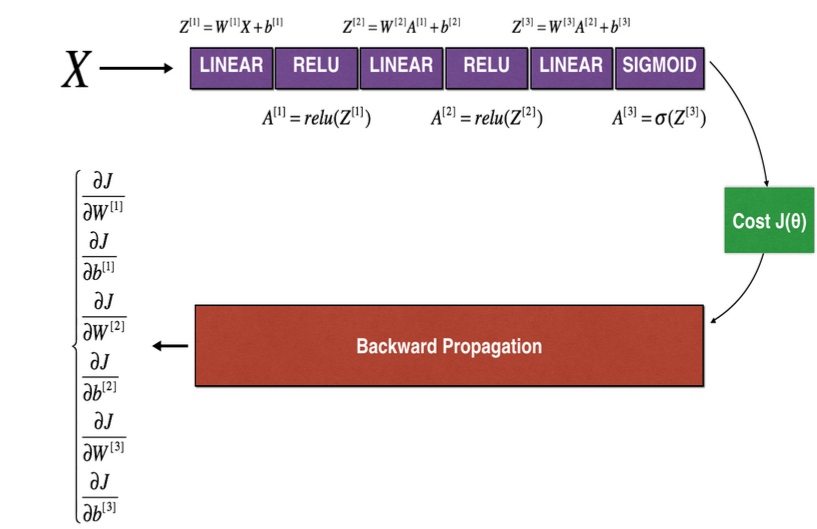

**LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOID**
Let's look at your implementations for forward propagation and backward propagation.


In [8]:
def forward_propagation_n(X, Y, parameters):
  """
  Implements the forward propagation (and computes the cost) presented in Figure 3.

  Arguments:
  X -- training set for m examples
  Y -- labels for m examples
  parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":
                  W1 -- weight matrix of shape (5, 4)
                  b1 -- bias vector of shape (5, 1)
                  W2 -- weight matrix of shape (3, 5)
                  b2 -- bias vector of shape (3, 1)
                  W3 -- weight matrix of shape (1, 3)
                  b3 -- bias vector of shape (1, 1)

  Returns:
  cost -- the cost function (logistic cost for one example)
  """

  m = X.shape[1]
  W1 = parameters["W1"]
  b1 = parameters["b1"]
  W2 = parameters["W2"]
  b2 = parameters["b2"]
  W3 = parameters["W3"]
  b3 = parameters["b3"]

  # LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SIGMOIND
  Z1 = np.dot(W1, X) + b1
  A1 = relu(Z1)
  Z2 = np.dot(W2, A1) + b2
  A2 = relu(Z2)
  Z3 = np.dot(W3, A2) + b3
  A3 = sigmoid(Z3)

  logprobs = np.multiply(-np.log(A3), Y) + np.multiply(-np.log(1 - A3), 1 - Y)
  cost = 1. /  m * np.sum(logprobs)

  cache = (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3)

  return cost, cache







Now the backprop:


In [9]:
def backward_propagation_n(X, Y, cache):
  m= X.shape[1]
  (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3)= cache

  dZ3 = A3 - Y
  dW3 = 1. / m * np.dot(dZ3 , A2.T)
  db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)

  dA2 = np.dot(W3.T, dZ3)
  dZ2 = np.multiply(dA2, np.int64(A2 > 0))
  dW2 = 1. / m * np.dot(dZ2, A1.T) * 2
  db2 = 1. / m * np.sum(dZ2, axis=1, keepdims=True)

  dA1 = np.dot(W2.T, dZ2)
  dZ1 = np.multiply(dA1, np.int64(A1 > 0))
  dW1 =  1. / m *  np.dot(dZ1, X.T)
  db1 = 4. / m * np.sum(dZ1, axis=1, keepdims=True)

  gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,
               "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
               "dA1": dA1, "dZ1":dZ1, "dW1": dW1, "db1": db1}

  return gradients



In [13]:
def backward_propagation_n(X, Y, cache):
    m = X.shape[1]

    (Z1, A1, W1, b1,
     Z2, A2, W2, b2,
     Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1./m * np.dot(dZ3, A2.T)
    db3 = 1./m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)
    dZ2 = dA2 * (A2 > 0)

    # ✅ CHECK THIS
    dW2 = 1./m * np.dot(dZ2, A1.T)
    db2 = 1./m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * (A1 > 0)

    # ✅ CHECK THIS
    dW1 = 1./m * np.dot(dZ1, X.T)
    db1 = 1./m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3
    }

    return gradients




You obtained some results on the fraud detection test set but you are not 100% sure of your model. Nobody's perfect! Let's implement gradient checking to verify if your gradients are correct.

**How does gradient checking work?.**

However $\theta$ is not a scalar anymore.It is a dict: called "parameters".
Here the `dictionary_to_vector()` converts the `parameters` dict into a vector called "values", obtained by reshaping  all parameters (W1, b1, W2, b2, W3, b3)
into vectors and concatenating them.

The inverse function is "vector_to_dictioanry" which outputs back the "parameters" dict.



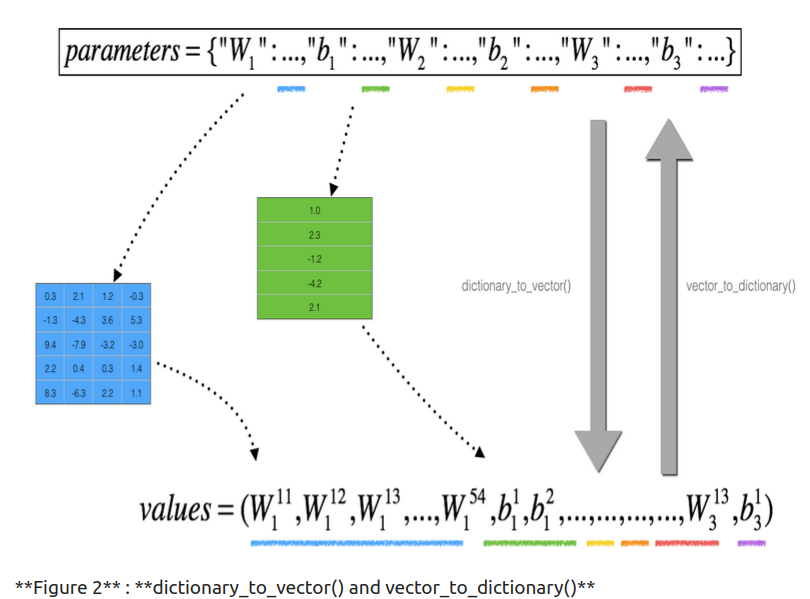

In [14]:
def gradient_check_n(parameters, gradients, X, Y, epsilon=1e-7):
    """
    Checks if backward_propagation_n computes correctly the gradient of the cost output by forward_propagation_n
    parameters -- python dictionary containing your parameters "W1", "b1", "W2", "b2", "W3", "b3":
    grad -- output of backward_propagation_n, contains gradients of the cost with respect to the parameters.
    x -- input datapoint, of shape (input size, 1)
    y -- true, "'label"
    epsilon -- tiny shift to the input to compute approximated gradient with formula(1)

    Returns:
    difference -- difference (2) between the approximated gradient and the backward propagation gradient
     """



    # Convert parameters and gradients to vector form
    parameters_values, _ = dictionary_to_vector(parameters)
    grad = gradients_to_vector(gradients)

    num_parameters = parameters_values.shape[0]
    J_plus = np.zeros((num_parameters, 1))
    J_minus = np.zeros((num_parameters, 1))
    gradapprox = np.zeros((num_parameters, 1))

    # Compute gradapprox
    for i in range(num_parameters):

        # J_plus[i]
        thetaplus = np.copy(parameters_values)
        thetaplus[i][0] += epsilon
        J_plus[i], _ = forward_propagation_n(
            X, Y, vector_to_dictionary(thetaplus)
        )

        # J_minus[i]
        thetaminus = np.copy(parameters_values)
        thetaminus[i][0] -= epsilon
        J_minus[i], _ = forward_propagation_n(
            X, Y, vector_to_dictionary(thetaminus)
        )

        # Gradapprox[i]
        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2 * epsilon)

    # Compute difference
    numerator = np.linalg.norm(grad - gradapprox)
    denominator = np.linalg.norm(grad) + np.linalg.norm(gradapprox)
    difference = numerator / denominator

    if difference > 1e-7:
        print(
            "\033[93mThere is a mistake in the backward propagation! difference = {}\033[0m"
            .format(difference)
        )
    else:
        print(
            "\033[92mYour backward propagation works perfectly fine! difference = {}\033[0m"
            .format(difference)
        )

    return difference


In [15]:
import numpy as np

def gradient_check_n_test_case():
    np.random.seed(1)

    X = np.random.randn(4, 3)
    Y = np.array([1, 1, 0])

    parameters = {
        "W1": np.random.randn(5, 4),
        "b1": np.random.randn(5, 1),
        "W2": np.random.randn(3, 5),
        "b2": np.random.randn(3, 1),
        "W3": np.random.randn(1, 3),
        "b3": np.random.randn(1, 1)
    }

    return X, Y, parameters


In [16]:
X, Y, parameters = gradient_check_n_test_case()

cost, cache = forward_propagation_n(X, Y, parameters)
gradients = backward_propagation_n(X,Y, cache)
difference = gradient_check_n(parameters, gradients, X, Y)


There is a mistake in the backward propagation! difference = 1.1890913024229996e-07


It seems that there were errors in the backward_propagation_n code we were give ! Good that we've implemented the gradient check.  We can go back to backward_propagation and try to find/correct the errors (Hint: check dW2 and db1). Rerun the gradient check when you think you've fixed it. Remember you'll need to re-execute the cell defining backward_propagation_n() if you modify the code.

Can you get gradient check to declare your derivative computation correct? Even though this part of the assignment isn't graded, we strongly urge you to try to find the bug and re-run gradient check until you're convinced backprop is now correctly implemented.

**Note**
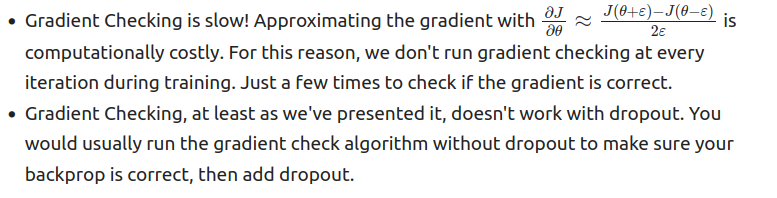

With this we can be confident that the Deep learning model for fraud detection is working correctly, We can now convince the CEO.


**Summary**
 Gradient checking verifies closeness between the gradients from backpropagation and the numerical approximation of the gradient `(computed using forward propagation)`. - Gradient checking is slow, so we don't run it in every iteration of training. You would usually run it only to make sure your code is correct, then turn it off and use backprop for the actual learning process.


Let run the code again